In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

Objective: To build a predictive engine for the National Capital Region (NCR) real estate market that helps buyers and sellers estimate property value based on 12,000+ scraped listings.

In [44]:
DATA_PATH = os.path.join('..', 'data', 'processed', 'ncr_properties_cleaned.parquet')

# Load the Parquet file
df = pd.read_parquet(DATA_PATH)

print(f"✅ Loaded {len(df)} rows from Parquet.")
df.sample()

✅ Loaded 12324 rows from Parquet.


,title,url,city,location,price,price_raw,area,area_raw,bedrooms,bathrooms,...,gym,lift,parking,vastu_compliant,property_hash,scraped_at,society_name,sector,locality,price_per_sqft
4569,2 BHK Flat for Sale in Gurgaon,https://www.magicbricks.com/propertyDetails/2-...,Gurugram,Unknown,4500000,₹45 Lac₹7826 per sqft,575.0,,2,0,...,0,0,0,0,a28a774174ab2a35b310ed493460a770,2026-02-02 15:35:36.990996,Independent/Authority,None,Gurgaon,7826.0


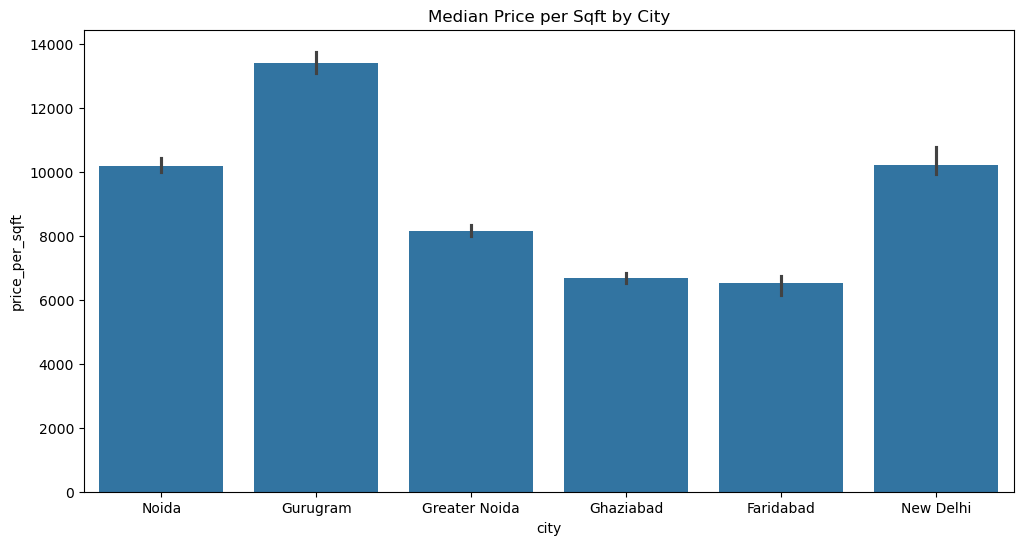

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='price_per_sqft', data=df, estimator='median')
plt.title('Median Price per Sqft by City')
plt.show()

### Observation
- Median price per square foot shows a clear and consistent ranking across cities.
- Gurugram has the highest price per sqft, followed by New Delhi and Noida.
- Greater Noida, Ghaziabad, and Faridabad form a lower-priced cluster with relatively similar values.

### Insight
- Price per square foot provides a normalized view of market value that removes the effect of property size.
- The clear separation between core and peripheral cities highlights strong location-driven pricing premiums.
- Similar price per sqft levels among Greater Noida, Ghaziabad, and Faridabad suggest these markets compete primarily on affordability rather than premium positioning.

### Modeling Impact
- City-level price efficiency is a stable and robust signal and should be leveraged in modeling.
- Derived features such as median price per sqft by city or sector can improve baseline predictions.
- This reinforces the need for location-aware modeling rather than relying solely on structural features.


<Axes: xlabel='area', ylabel='price'>

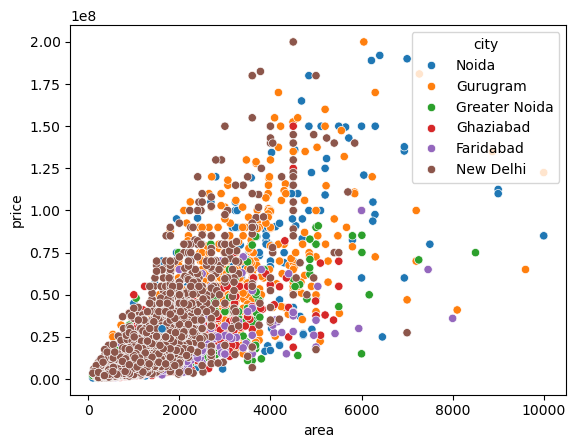

In [80]:
sns.scatterplot(x='area', y='price', hue='city', data=df)

### Observation
- Across the entire dataset, price increases with area, but with substantial dispersion.
- Larger properties exhibit a much wider range of prices compared to smaller properties.
- Significant overlap exists between cities, particularly in the mid-area range.
- New Delhi and Gurugram show a higher concentration of high-priced properties at comparable sizes.

### Insight
- Area alone does not uniquely determine property price, especially at higher sizes.
- Location-driven premiums create overlapping price ranges across cities, making simple size-based rules insufficient.
- The widening spread at larger areas highlights the increasing influence of micro-location, amenities, and property type.
- The NCR real estate market operates as overlapping sub-markets rather than clearly separable city-wise segments.

### Modeling Impact
- Predictive models must account for both size and location simultaneously.
- Non-linear models are better suited to handle overlapping distributions and heteroscedasticity.
- High-capacity models can learn city- and sector-specific price adjustments more effectively than global linear relationships.


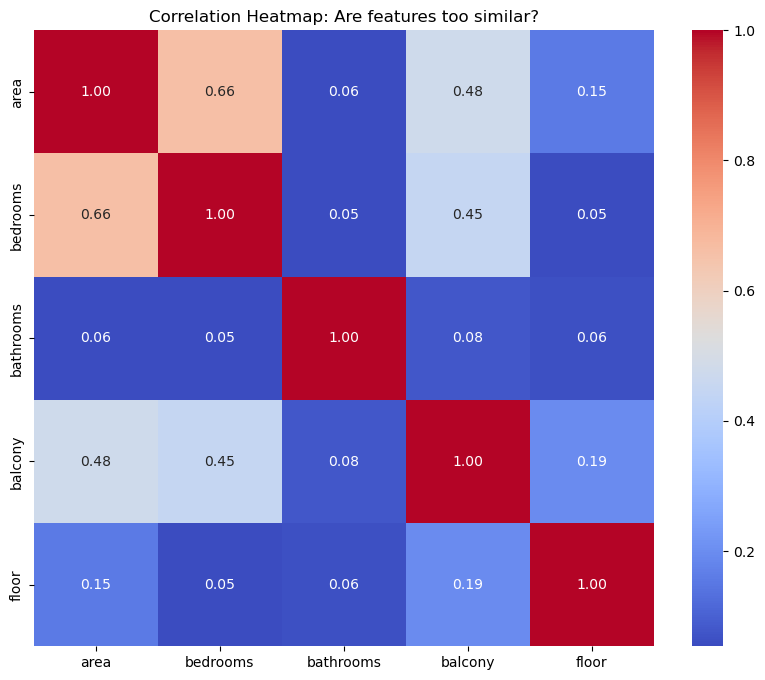


--- Variance Inflation Factor (VIF) ---
     feature       VIF
1   bedrooms  7.640443
0       area  7.119323
3    balcony  4.011690
4      floor  1.185949
2  bathrooms  1.046964


In [47]:
features = ['area', 'bedrooms', 'bathrooms', 'balcony', 'floor']
X = df[features].fillna(0) # Ensure no NaNs for the math

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Are features too similar?")
plt.show()

# 4. Variance Inflation Factor (VIF)
# VIF > 5-10 indicates high multicollinearity
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

### Observation
- Area and bedrooms show a strong positive correlation (≈ 0.66).
- Area also exhibits moderate correlation with balcony count (≈ 0.48).
- Most other feature pairs display low correlation values, indicating limited linear dependency.
- Variance Inflation Factor (VIF) values are elevated for area and bedrooms compared to other features, but remain within manageable ranges.

### Insight
- Area and bedroom count capture overlapping information related to property size.
- Balcony count is partially influenced by property size but retains independent signal.
- Bathrooms and floor show minimal correlation with other features, suggesting they contribute distinct information.
- Multicollinearity is present but not severe enough to warrant aggressive feature removal.

### Modeling Impact
- Area should be retained as a primary numerical feature.
- Bedroom count should be included but interpreted in conjunction with area.
- Linear models may require regularization to mitigate multicollinearity effects.
- Tree-based and ensemble models are naturally robust to correlated features and are well suited for this feature set.


In [81]:
# TEMPORARY CLEANING FOR EDA ACCURACY
# We drop these now so our graphs represent the true market, not the spam.
df = df.drop_duplicates(subset=['city', 'sector', 'price', 'area'], keep='first')
print(f"EDA Dataset: {len(df)} unique rows remaining.")

EDA Dataset: 10538 unique rows remaining.


In [82]:
# 3. Investigation: The "Hidden Null" Check
# We suspect '0' is used as a placeholder for missing data.
zero_bath_count = (df['bathrooms'] == 0).sum()
zero_bed_count = (df['bedrooms'] == 0).sum()

print(f"Properties with 0 Bathrooms: {zero_bath_count} ({round(zero_bath_count/len(df)*100, 1)}%)")
print(f"Properties with 0 Bedrooms: {zero_bed_count} ({round(zero_bed_count/len(df)*100, 1)}%)")

Properties with 0 Bathrooms: 10051 (95.4%)
Properties with 0 Bedrooms: 143 (1.4%)


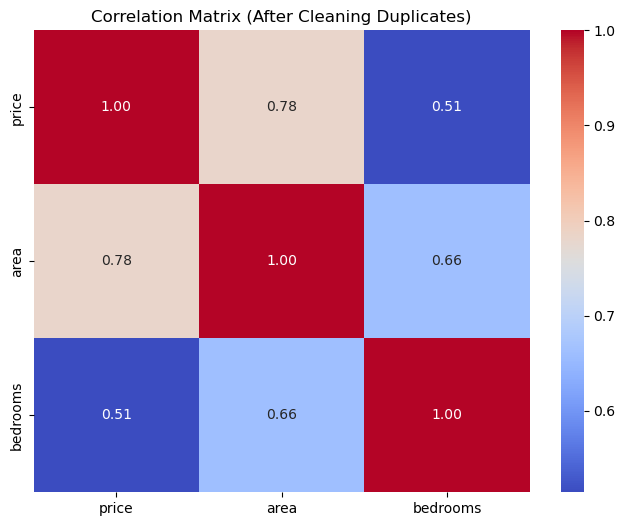

In [83]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['price', 'area', 'bedrooms']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (After Cleaning Duplicates)')
plt.show()

###  Observation
- Price shows a strong positive correlation with area (≈ 0.78).
- Price has a moderate correlation with number of bedrooms (≈ 0.51).
- Area and bedrooms are also strongly correlated with each other (≈ 0.66).

###  Insight
- Property price increases significantly with built-up area, confirming area as the primary numerical driver of price.
- Bedroom count alone is less informative than area, suggesting that room configuration without size context is insufficient.
- The strong correlation between area and bedrooms indicates redundancy, as larger properties typically have more bedrooms.

###  Modeling Impact
- Area should be treated as a core feature in all predictive models.
- Bedroom count should not be relied on independently and should be evaluated in combination with area.
- Multicollinearity between area and bedrooms must be handled carefully, especially for linear models.
- Tree-based and ensemble models are better suited to capture these relationships without being adversely affected by correlated features.


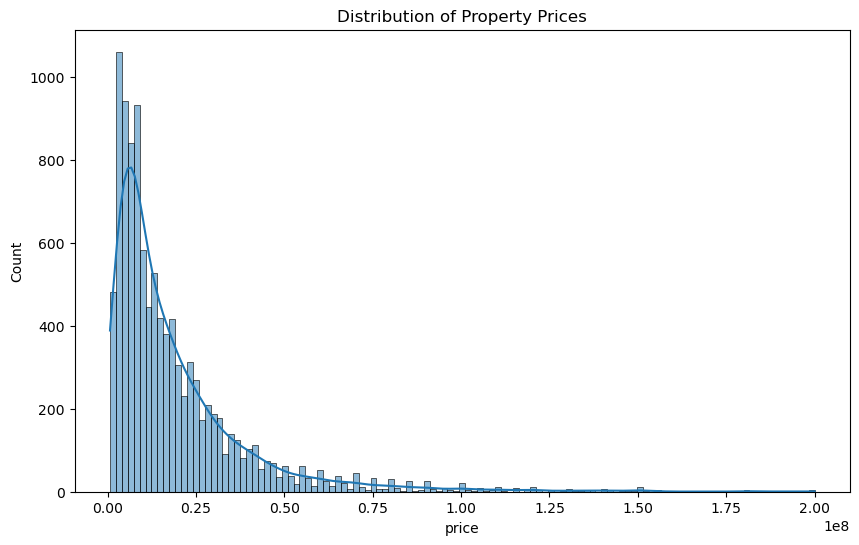

In [51]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Property Prices')
plt.show()

### Observation
- The distribution of property prices is highly right-skewed with a long tail.
- A large proportion of properties are concentrated in the lower price range, while a small number of listings have extremely high prices.
- The presence of luxury properties significantly stretches the upper end of the distribution.

### Insight
- The NCR real estate market contains a wide pricing spectrum, with a dominant mid-range segment and a relatively small luxury segment.
- Mean price is heavily influenced by high-value outliers and does not represent a typical property price.
- The skewed nature of the target variable violates the normality assumption required by many linear models.

### Modeling Impact
- Log transformation of the price variable is necessary to reduce skewness and stabilize variance.
- Median-based metrics should be preferred over mean-based metrics for descriptive analysis.
- Models robust to skewed distributions and outliers, such as tree-based and ensemble methods, are expected to perform better.


Original Skewness: 2.98


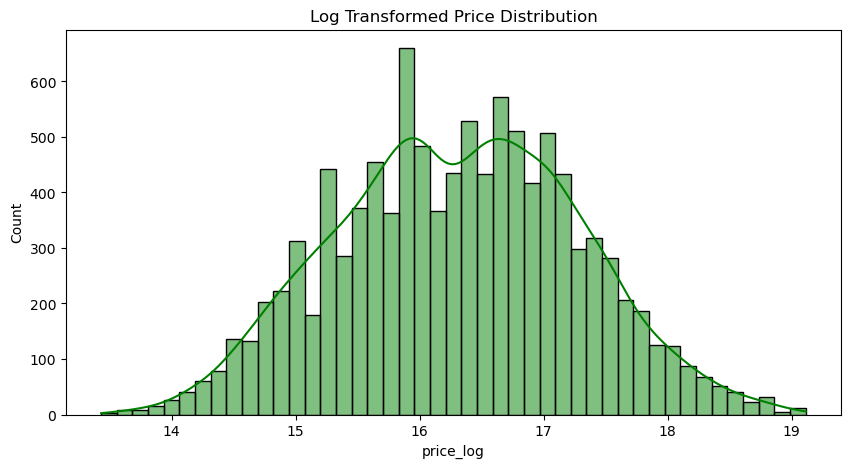

New Skewness: 0.00


In [52]:
# 1. original Price skew
print(f"Original Skewness: {df['price'].skew():.2f}")

# 2. Log Transformation (We use log1p to handle any 0s, though prices won't be 0)
df['price_log'] = np.log1p(df['price'])

# 3. new distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price_log'], kde=True, color='green', edgecolor='black')
plt.title('Log Transformed Price Distribution')
plt.show()

print(f"New Skewness: {df['price_log'].skew():.2f}")

### Observation
- After log transformation, the price distribution becomes approximately symmetric and bell-shaped.
- The extreme right tail observed in the original price distribution is significantly reduced.
- Variance across price ranges appears more stable.

### Insight
- Log transformation effectively normalizes the target variable and reduces the influence of extreme luxury properties.
- The transformed distribution better represents the central structure of the market.
- This transformation aligns the target variable more closely with assumptions of many statistical and machine learning models.

### Modeling Impact
- Log-transformed price should be used as the target variable during model training.
- Improved distribution symmetry is expected to enhance model stability and predictive performance.
- Evaluation metrics should be computed on the original price scale after inverse transformation for interpretability.


In [53]:
def analyze_outliers_iqr(df, col):
    # 1. Calculate IQR Stats
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Define standard (1.5x) and extreme (3x) bounds
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    extreme_upper = Q3 + 3.0 * IQR # "Extreme" outliers
    
    # 3. Print the Summary
    print(f"--- Statistical Summary for {col} ---")
    print(f"Interquartile Range (IQR): {IQR:.2f}")
    print(f"Standard Upper Bound (1.5x): {upper_fence:.2f}")
    print(f"Extreme Upper Bound (3.0x): {extreme_upper:.2f}")
    
    # 4. Count the outliers
    outliers = df[df[col] > upper_fence]
    extreme_outliers = df[df[col] > extreme_upper]
    
    print(f"Total Outliers (> 1.5x): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"Extreme Outliers (> 3.0x): {len(extreme_outliers)} ({len(extreme_outliers)/len(df)*100:.1f}%)")
    print("-" * 35)
    
    return outliers

# Run the analysis for Price and Area
price_outliers = analyze_outliers_iqr(df, 'price')
area_outliers = analyze_outliers_iqr(df, 'area')

--- Statistical Summary for price ---
Interquartile Range (IQR): 18500000.00
Standard Upper Bound (1.5x): 52250000.00
Extreme Upper Bound (3.0x): 80000000.00
Total Outliers (> 1.5x): 676 (6.4%)
Extreme Outliers (> 3.0x): 238 (2.3%)
-----------------------------------
--- Statistical Summary for area ---
Interquartile Range (IQR): 970.00
Standard Upper Bound (1.5x): 3325.00
Extreme Upper Bound (3.0x): 4780.00
Total Outliers (> 1.5x): 455 (4.3%)
Extreme Outliers (> 3.0x): 121 (1.1%)
-----------------------------------


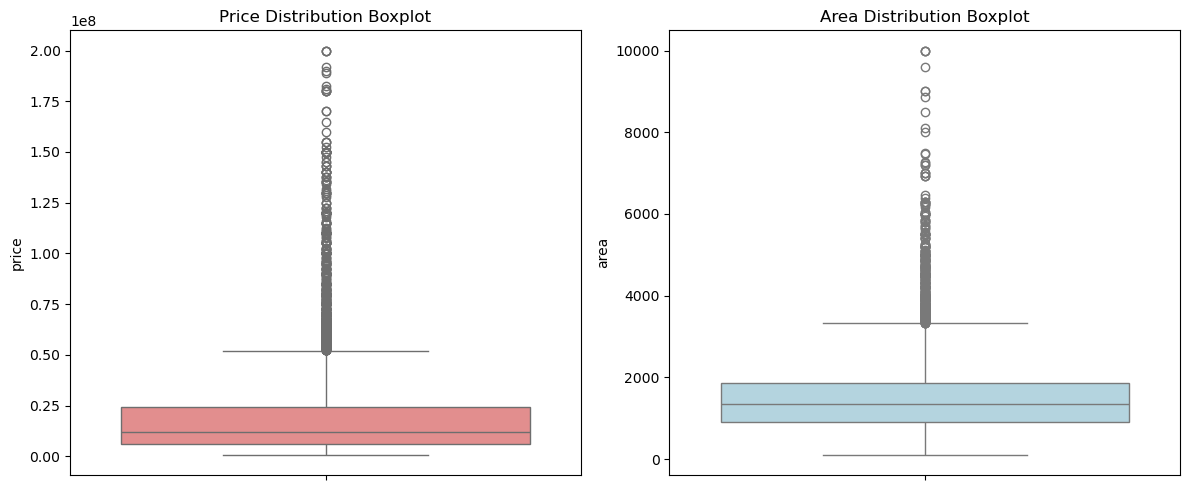

In [54]:

plt.figure(figsize=(12, 5))

# Plotting Price Distribution with Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='lightcoral')
plt.title('Price Distribution Boxplot')

# Plotting Area Distribution with Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['area'], color='lightblue')
plt.title('Area Distribution Boxplot')

plt.tight_layout()
plt.show()

### Observation
- Both price and area distributions contain a large number of outliers.
- The median price lies significantly below the upper whisker, indicating strong right skewness.
- Area also shows a right-skewed distribution, with most properties clustered in a moderate size range and a small number of very large properties.

### Insight
- The NCR real estate market includes a substantial number of premium and luxury listings that deviate strongly from the majority of properties.
- Extreme values in both price and area are not necessarily data errors but represent genuine high-end properties.
- The presence of many outliers confirms the heterogeneous nature of the market.

### Modeling Impact
- Outliers should not be removed aggressively, as they carry meaningful market information.
- Log transformation and robust modeling techniques are preferred over outlier deletion.
- Tree-based and ensemble models are expected to handle such skewed distributions more effectively than purely linear models.


In [55]:
# mask for properties that are extreme in both price and area
extreme_mask = (df['price'] > 8.14) & (df['area'] > 4667)
both_extreme = df[extreme_mask]

print(f"Properties extreme in both Price & Area: {len(both_extreme)}")

# most suspicious ones (Small Area but Massive Price)
suspicious = df[(df['area'] < 1000) & (df['price'] > 2.0)]
print("\nSuspicious Properties (Tiny Area, High Price):")
print(suspicious[['city', 'sector', 'price', 'area']].head())

Properties extreme in both Price & Area: 135

Suspicious Properties (Tiny Area, High Price):
      city           sector     price   area
24   Noida       Sector 120  10900000  943.0
32   Noida  Noida Extension  11200000  995.0
39   Noida  Noida Extension  10100000  988.0
122  Noida  Noida Extension   3500000  900.0
128  Noida         Sarfabad   4300000  800.0


In [56]:
# Checking for duplicates based on the core features only
feature_duplicates = df.duplicated(subset=['city', 'sector', 'price', 'area']).sum()
print(f"Duplicates based on core features: {feature_duplicates}")

# Let's see an example of these 'near-duplicates'
if feature_duplicates > 0:
    print("\nExample of Feature-Level Duplicates:")
    print(df[df.duplicated(subset=['city', 'sector', 'price', 'area'], keep=False)].sort_values(by='price').head(4))

Duplicates based on core features: 0


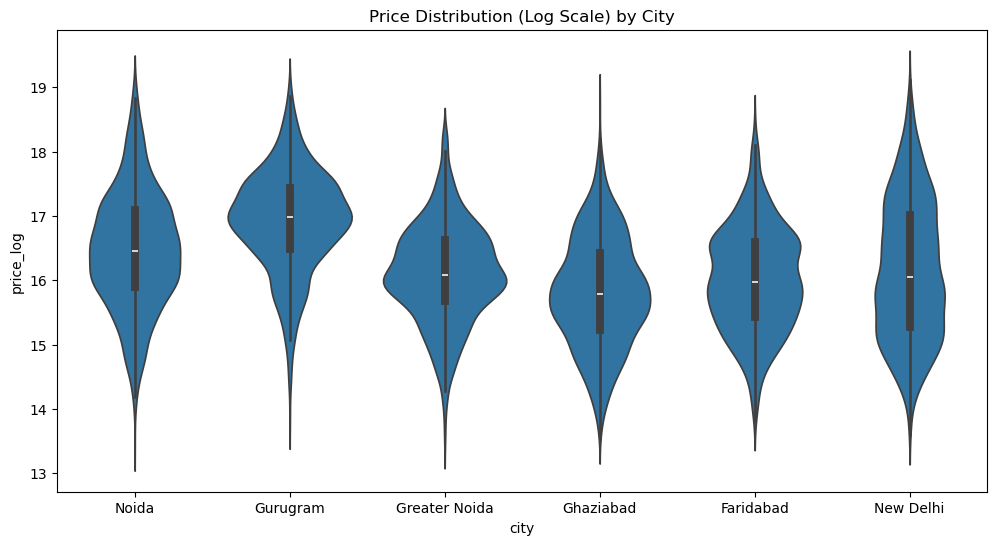

In [57]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='city', y='price_log', data=df)
plt.title('Price Distribution (Log Scale) by City')
plt.show()


### Observation
- The distribution of log-transformed prices differs noticeably across cities.
- Gurugram and New Delhi show higher median prices and wider spreads compared to other cities.
- Ghaziabad and Faridabad exhibit relatively lower median prices with more compact distributions.
- Overlap exists across all cities, indicating shared price ranges despite different medians.

### Insight
- City-level location has a strong influence on property pricing in the NCR region.
- Premium markets such as Gurugram and New Delhi command higher price levels, reflecting stronger demand, infrastructure, and commercial activity.
- Despite city-level differences, substantial within-city variability suggests that micro-location factors also play an important role.

### Modeling Impact
- City should be included as an important categorical feature in the pricing model.
- City alone is insufficient to fully explain price variation; finer-grained location features (sector or locality) should be incorporated where possible.
- Target or frequency encoding is preferable to one-hot encoding for handling location-related categorical variables.


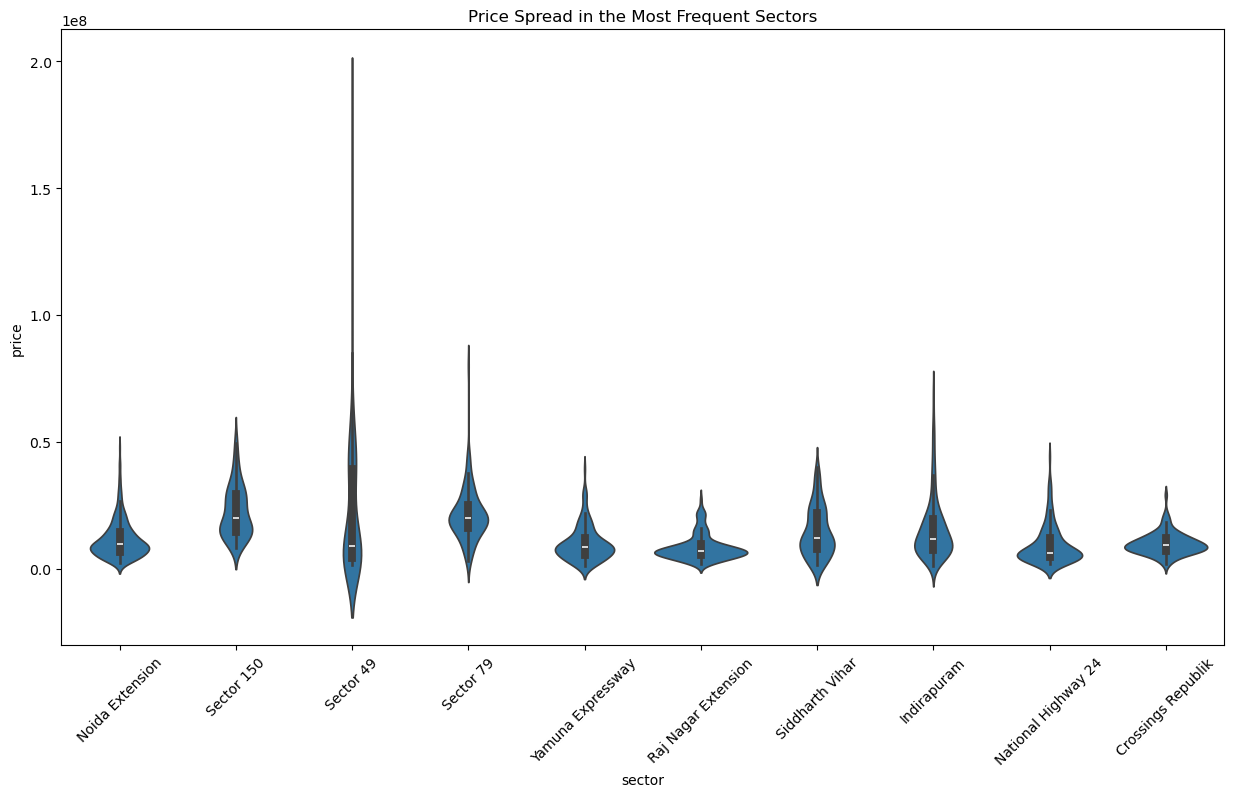

In [58]:
plt.figure(figsize=(15, 8))

top_10_sectors = df['sector'].value_counts().head(10).index
df_top_sectors = df[df['sector'].isin(top_10_sectors)]

sns.violinplot(x='sector', y='price', data=df_top_sectors)
plt.xticks(rotation=45)
plt.title('Price Spread in the Most Frequent Sectors')
plt.show()


### Observation
- Price distributions vary substantially across the most frequent sectors.
- Certain sectors show higher median prices and wider spreads, indicating the presence of premium and luxury properties.
- Some sectors exhibit long upper tails, reflecting a small number of very high-priced listings.
- Other sectors display relatively compact distributions, suggesting more consistent pricing.

### Insight
- Sector-level location captures micro-market effects that are not visible at the city level.
- Premium sectors command significantly higher prices even within the same city, driven by factors such as connectivity, infrastructure, and neighborhood reputation.
- Large price variation within sectors suggests that property-specific attributes (area, amenities, property type) further influence valuation.

### Modeling Impact
- Sector should be treated as a high-importance location feature in the pricing model.
- Sector-level encoding is expected to improve model performance compared to city-only encoding.
- High-cardinality sector features should be encoded using techniques such as target encoding or mean encoding rather than one-hot encoding.


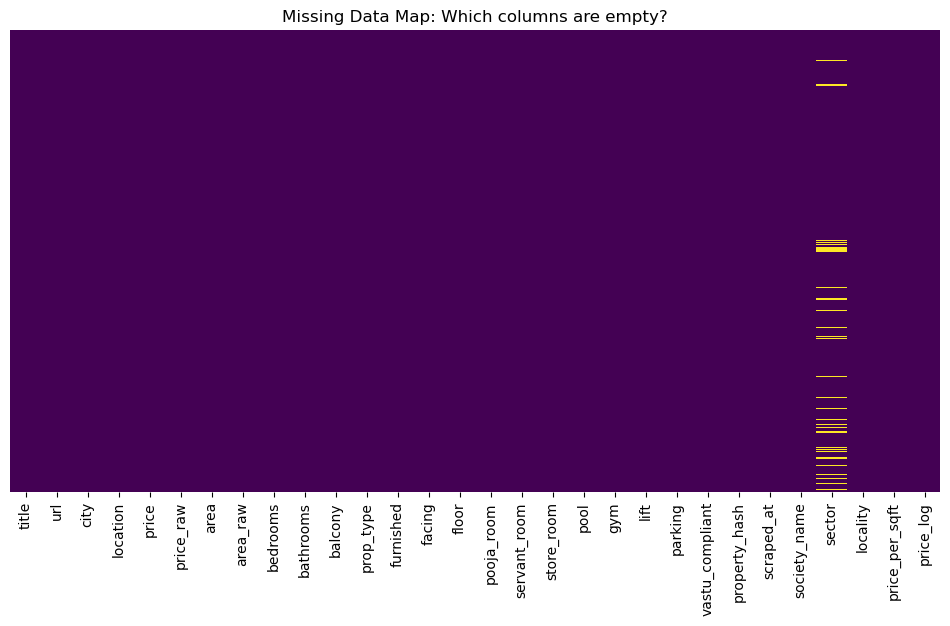


Null Value Counts:
sector             843
title                0
url                  0
price_per_sqft       0
locality             0
society_name         0
scraped_at           0
property_hash        0
vastu_compliant      0
parking              0
lift                 0
gym                  0
pool                 0
store_room           0
servant_room         0
pooja_room           0
floor                0
facing               0
furnished            0
prop_type            0
balcony              0
bathrooms            0
bedrooms             0
area_raw             0
area                 0
price_raw            0
price                0
location             0
city                 0
price_log            0
dtype: int64


In [59]:
plt.figure(figsize=(12, 6))
# Using isnull() to create a boolean map and visualizing it
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Map: Which columns are empty?')
plt.show()

# Precise numbers
print("\nNull Value Counts:")
print(df.isnull().sum().sort_values(ascending=False))

In [60]:
# Create a dataframe of rows where sector is null
missing_sector_df = df[df['sector'].isnull()]

print("--- Analysis of Missing Sectors ---")
print(f"Average Price of 'No Sector' properties: {missing_sector_df['price'].mean():.2f} Cr")
print(f"Top 5 Cities for missing sectors:\n{missing_sector_df['city'].value_counts()}")

# Check if 'locality' has info we can use to fill 'sector'
print(f"\nExample Localities where Sector is missing:\n{missing_sector_df['locality'].head()}")

--- Analysis of Missing Sectors ---
Average Price of 'No Sector' properties: 15594163.70 Cr
Top 5 Cities for missing sectors:
city
New Delhi        320
Greater Noida    159
Ghaziabad        148
Gurugram          95
Noida             71
Faridabad         50
Name: count, dtype: int64

Example Localities where Sector is missing:
44               Noida
267              Noida
298              Noida
307              Noida
454    Bahlolpur Noida
Name: locality, dtype: object


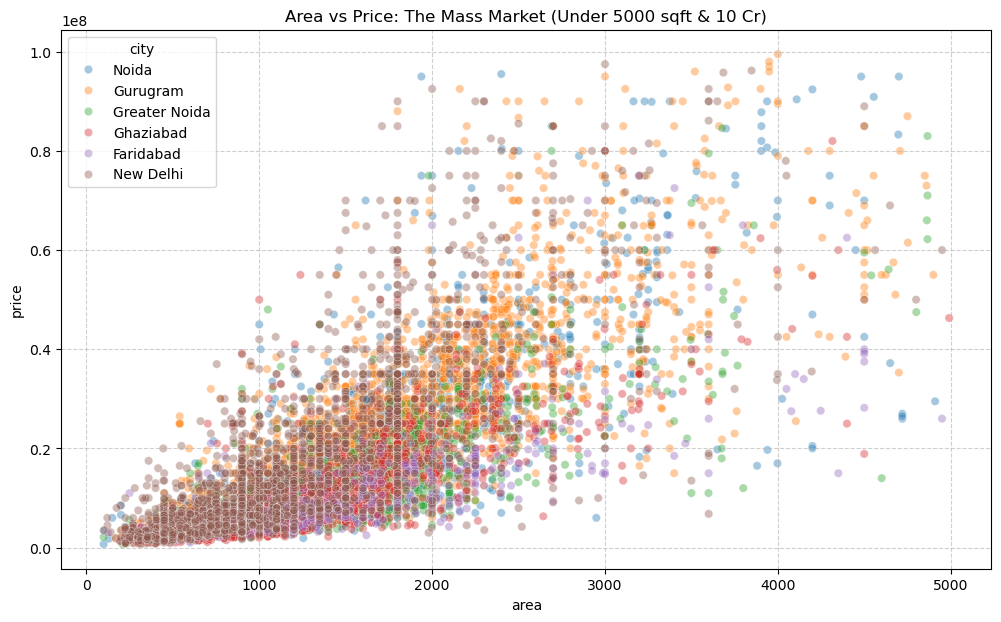

In [61]:
plt.figure(figsize=(12, 7))
# We filter to < 5000 sqft and < 10 Cr to see the 'Normal' market clearly
sns.scatterplot(data=df[(df['area'] < 5000) & (df['price'] < 100000000 )], 
                x='area', y='price', hue='city', alpha=0.4)

plt.title('Area vs Price: The Mass Market (Under 5000 sqft & 10 Cr)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Observation
- In the mass market segment (properties under 5000 sqft and under 10 Cr), price increases with area across all cities.
- The relationship between area and price is clearly positive but exhibits increasing variance at higher area values.
- For similar area ranges, properties from different cities show noticeable price dispersion.
- The majority of listings are concentrated in the 500–2500 sqft range, representing the core residential market.

### Insight
- Area is a strong and consistent driver of property price in the NCR mass market.
- The widening spread at higher areas indicates that location and property-specific factors increasingly influence pricing as size increases.
- City-level differences persist even after controlling for area, reinforcing the importance of location features.

### Modeling Impact
- Area should be treated as a primary numerical feature in all pricing models.
- Non-linear relationships and heteroscedasticity suggest the use of tree-based or ensemble models.
- Interaction effects between area and location (city or sector) should be captured to improve predictive accuracy.


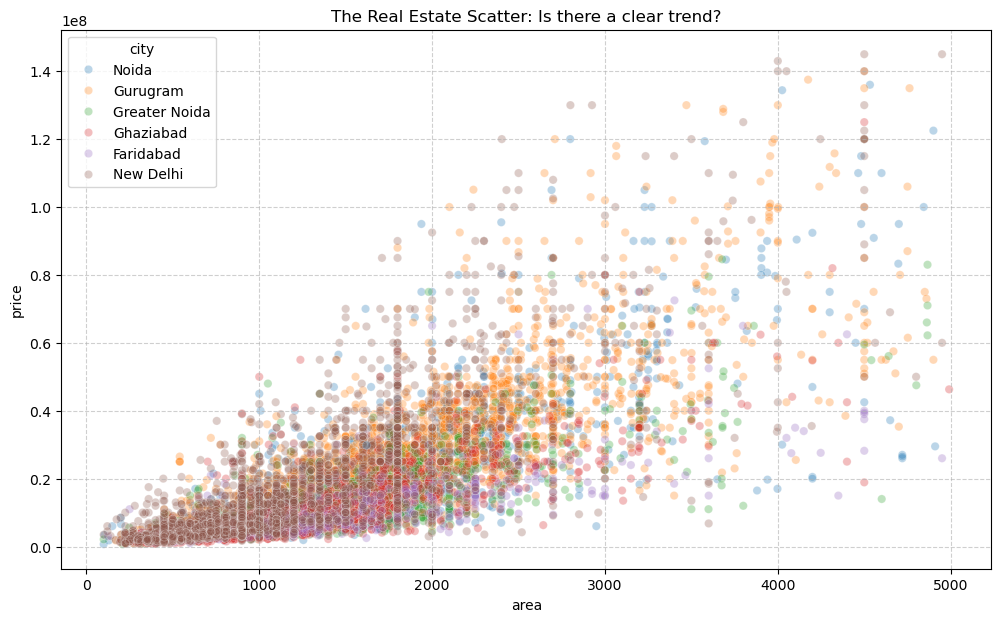

In [62]:
plt.figure(figsize=(12, 7))
# We filter to < 5000 sqft and < 15 Cr to see the 'Normal' market clearly
sns.scatterplot(data=df[(df['area'] < 5000) & (df['price'] < 150000000)], 
                x='area', y='price', hue='city', alpha=0.3)

plt.title('The Real Estate Scatter: Is there a clear trend?')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Observation
- Across the full filtered range, price shows a clear positive relationship with area.
- The scatter exhibits a funnel-shaped pattern, with price variability increasing as area increases.
- Larger properties span a wide range of prices, while smaller properties are more tightly clustered.
- City-wise coloring reveals overlapping trends, but with visible vertical separation for certain cities at similar area levels.

### Insight
- There is a strong overall trend of increasing price with increasing area, confirming area as a fundamental driver of property value.
- The increasing spread at higher area levels indicates heteroscedasticity, suggesting that additional factors such as location, amenities, and property type become more influential for larger homes.
- While the global trend is clear, no single linear relationship can fully explain price behavior across the market.

### Modeling Impact
- Linear models alone may struggle to capture the widening variance and non-linear behavior.
- Tree-based and ensemble models are better suited to model these complex interactions.
- Feature interactions between area, location, and property attributes should be explicitly or implicitly captured during modeling.


In [63]:
print(f"Properties with 0 bathrooms: {(df['bathrooms'] == 0).sum()}")
print(f"Properties with 0 bedrooms: {(df['bedrooms'] == 0).sum()}")

Properties with 0 bathrooms: 10051
Properties with 0 bedrooms: 143


In [64]:
# Check unique values for all amenity/room columns
cols_to_check = ['bathrooms', 'bedrooms', 'lift', 'parking', 'gym', 'pool', 'servant_room']

for col in cols_to_check:
    print(f"{col}: {df[col].unique()}")

bathrooms: [0 3 6 2 4 5 7 1 8]
bedrooms: [ 3  5  4  2  0  1  7 10  6  8  9]
lift: [0 1]
parking: [0 1]
gym: [0 1]
pool: [0 1]
servant_room: [0 1]


C:\Users\Asus\AppData\Local\Temp\ipykernel_12592\3072566480.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='pps', data=df, estimator='median', palette='magma')


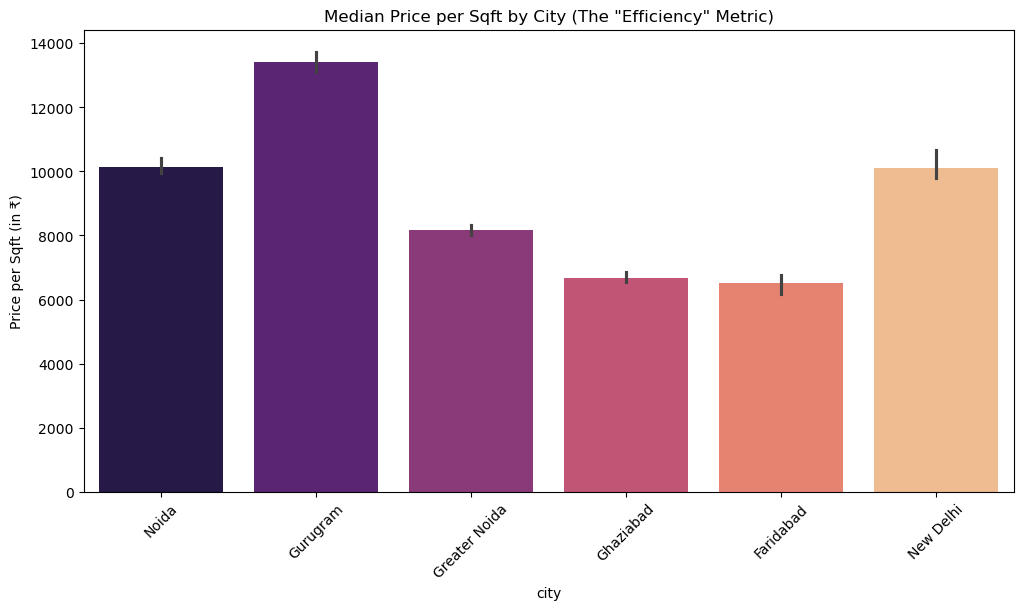

In [65]:
# Calculate Price per Sqft if not already done
df['pps'] = df['price'] / df['area']

plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='pps', data=df, estimator='median', palette='magma')
plt.title('Median Price per Sqft by City (The "Efficiency" Metric)')
plt.ylabel('Price per Sqft (in ₹)')
plt.xticks(rotation=45)
plt.show()

### Observation
- Median price per square foot varies significantly across cities.
- Gurugram has the highest median price per sqft, followed by New Delhi.
- Noida occupies a mid-to-high position, while Greater Noida, Ghaziabad, and Faridabad show relatively lower values.
- The ordering remains stable when using the median, indicating robustness against extreme outliers.

### Insight
- Price per square foot captures the intrinsic value of location more effectively than absolute price.
- Higher median values in Gurugram and New Delhi reflect stronger demand, better infrastructure, and premium micro-markets.
- Lower price per sqft in peripheral cities suggests affordability but also indicates lower location-driven premiums.

### Modeling Impact
- Price per sqft is a powerful derived feature and should be included in the modeling pipeline.
- Using median-based aggregates helps reduce the influence of extreme luxury listings.
- Location-based pricing efficiency reinforces the importance of city and sector-level features in prediction and recommendation systems.


In [66]:
# Correlation check on the rows that actually HAVE data (> 0)
has_data = df[(df['bathrooms'] > 0) & (df['bedrooms'] > 0)]

print(f"Correlation (Area vs Price): {has_data['area'].corr(has_data['price']):.2f}")
print(f"Correlation (Bedrooms vs Price): {has_data['bedrooms'].corr(has_data['price']):.2f}")

Correlation (Area vs Price): 0.80
Correlation (Bedrooms vs Price): 0.57


C:\Users\Asus\AppData\Local\Temp\ipykernel_12592\788868776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='pps', data=df, estimator='median', palette='viridis')


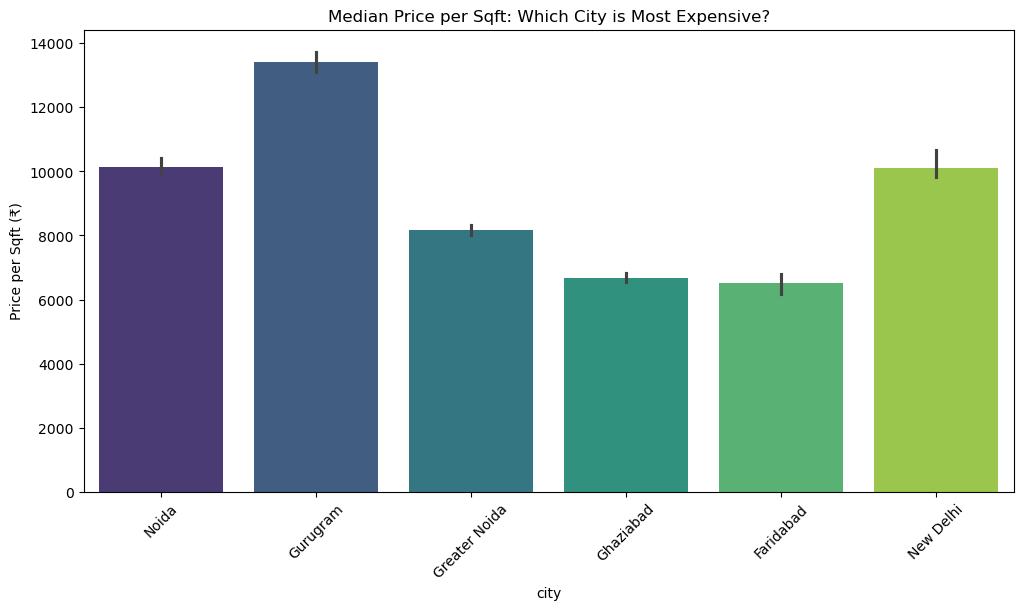

In [67]:
# Calculate Price per Sqft
df['pps'] = df['price'] / df['area']

plt.figure(figsize=(12, 6))
# Median is better because of the outliers we found in Delhi
sns.barplot(x='city', y='pps', data=df, estimator='median', palette='viridis')
plt.title('Median Price per Sqft: Which City is Most Expensive?')
plt.ylabel('Price per Sqft (₹)')
plt.xticks(rotation=45)
plt.show()

### Observation
- Median price per square foot differs markedly across cities.
- Gurugram emerges as the most expensive city on a per-sqft basis, followed closely by New Delhi.
- Noida occupies a mid-range position, while Greater Noida, Ghaziabad, and Faridabad are comparatively more affordable.
- The relative ordering of cities is consistent and stable, indicating a clear pricing hierarchy.

### Insight
- Price per square foot effectively captures the relative valuation of space across cities.
- Higher per-sqft prices in Gurugram and New Delhi reflect stronger economic activity, premium neighborhoods, and higher demand intensity.
- Peripheral cities offer lower per-unit land value, making them more attractive for affordability-focused buyers.

### Modeling Impact
- City-level price efficiency should be incorporated into the model either directly or via derived features such as price per sqft.
- Median-based aggregation provides a robust signal that is less sensitive to extreme listings.
- These patterns support the inclusion of location-centric features for both price prediction and recommendation systems.


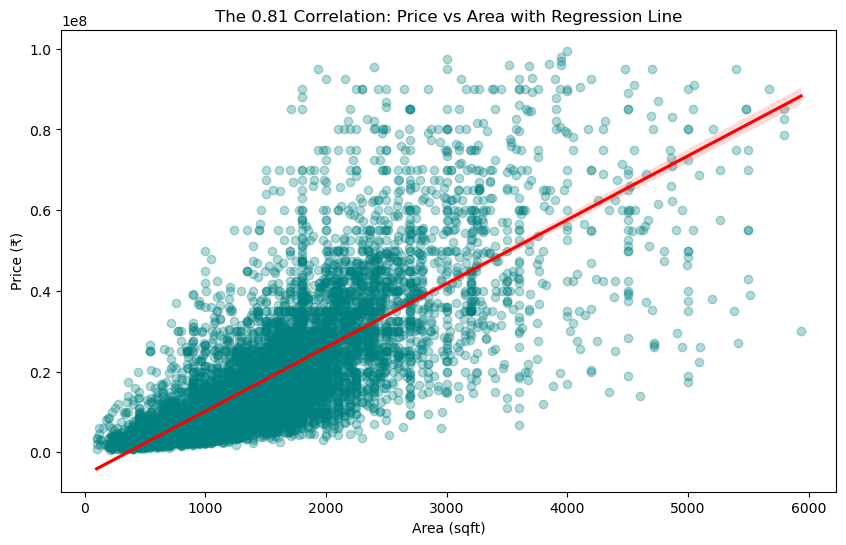

In [68]:
df_plot = df[(df['area'] < 6000) & (df['price'] < 100000000)]

plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot, x='area', y='price', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('The 0.81 Correlation: Price vs Area with Regression Line')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (₹)')
plt.show()

### Observation
- Price and area exhibit a strong positive linear relationship, with a correlation coefficient of approximately 0.81.
- The regression line captures the overall upward trend, while individual data points show increasing dispersion at higher area values.
- Smaller properties are tightly clustered around the regression line, whereas larger properties show greater variability.

### Insight
- Area is the single most influential numerical feature in determining property price.
- While the global relationship between area and price is strong, substantial deviation from the regression line indicates the influence of additional factors such as location, amenities, and property type.
- The presence of heteroscedasticity suggests that variance in price grows with property size.

### Modeling Impact
- Area should be treated as a core predictor in all pricing models.
- A simple linear model may capture the general trend but will struggle with increasing variance and non-linear effects.
- Tree-based or ensemble models are better suited to capture complex interactions and non-uniform variance across the feature space.


In [69]:
print(f"Correlation (Area vs Bedrooms): {has_data['area'].corr(has_data['bedrooms']):.2f}")

Correlation (Area vs Bedrooms): 0.69


C:\Users\Asus\AppData\Local\Temp\ipykernel_12592\4030771353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bedrooms', y='price', data=df[df['bedrooms'] > 0], palette='magma')


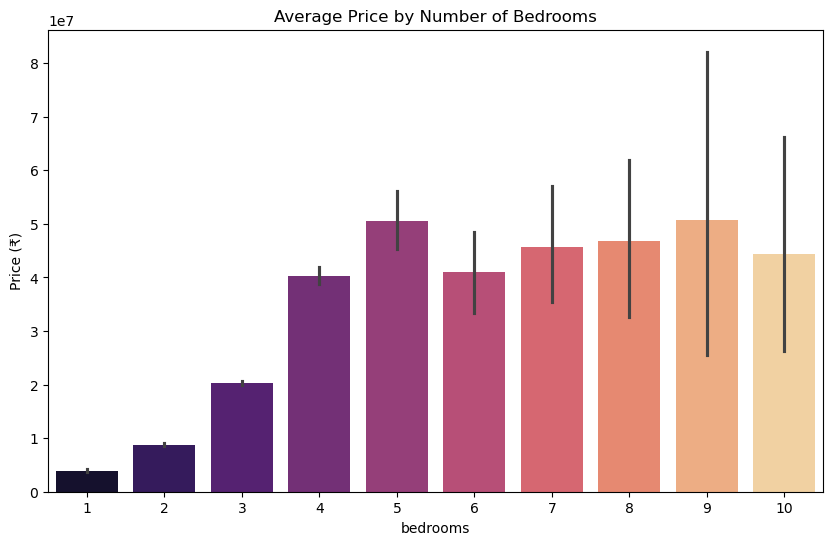

In [70]:
# the average price for different bedroom counts
plt.figure(figsize=(10, 6))
sns.barplot(x='bedrooms', y='price', data=df[df['bedrooms'] > 0], palette='magma')
plt.title('Average Price by Number of Bedrooms')
plt.ylabel('Price (₹)')
plt.show()

### Observation
- Average property price generally increases as the number of bedrooms increases.
- The relationship is not strictly monotonic, with certain higher bedroom counts showing overlap or even lower average prices.
- Variability in price increases significantly for properties with a large number of bedrooms, as reflected by wider error bars.

### Insight
- Bedroom count is a useful indicator of property value, but it does not uniquely determine price.
- Large variation at higher bedroom counts suggests that bedroom count alone fails to capture important factors such as area, location, and property type.
- Properties with more bedrooms can belong to very different market segments, ranging from independent houses to large apartments.

### Modeling Impact
- Bedroom count should be retained as a feature but not treated as a dominant predictor.
- Its effect should be modeled in combination with area and location features.
- Interaction effects or non-linear models are better suited to capture the nuanced influence of bedroom count on price.


In [71]:
# 1. Calculate PPS if you haven't already
df['pps'] = df['price'] / df['area']

# 2. Group by Sector (Filtering for sectors with at least 5 listings for reliability)
sector_stats = df.groupby('sector').agg({
    'pps': 'mean',
    'price': 'count'
}).rename(columns={'price': 'listing_count'})

# 3. Get the Top 10 (Minimum 5 listings to avoid fluke data)
top_10_expensive = sector_stats[sector_stats['listing_count'] >= 5].sort_values(by='pps', ascending=False).head(10)

print("Top 10 Most Expensive Sectors (Price per Sqft):")
print(top_10_expensive)

Top 10 Most Expensive Sectors (Price per Sqft):
                             pps  listing_count
sector                                         
Defence Colony      38791.448190              6
Sector 41           34422.457937              7
Vasant Vihar        32773.678702              7
Greater Kailash 1   29955.509711             15
Golf Course Road    29869.231592              7
Greater Kailash 2   29435.982224             13
New Rajendra Nagar  29179.860938              5
Sector 54           28747.667026             16
Safdarjung Enclave  27752.645882             10
Hauz Khas           27181.085980             11


In [72]:
# Check variance in the most expensive sector
top_sector_name = top_10_expensive.index[0]
print(f"\nPrice variation in {top_sector_name}:")
print(df[df['sector'] == top_sector_name]['price'].describe())


Price variation in Defence Colony:
count    6.000000e+00
mean     1.084167e+08
std      4.452013e+07
min      5.500000e+07
25%      8.137500e+07
50%      1.027500e+08
75%      1.275000e+08
max      1.800000e+08
Name: price, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_12592\3721383795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sector', y='pps', data=df_comp, palette='Set2')


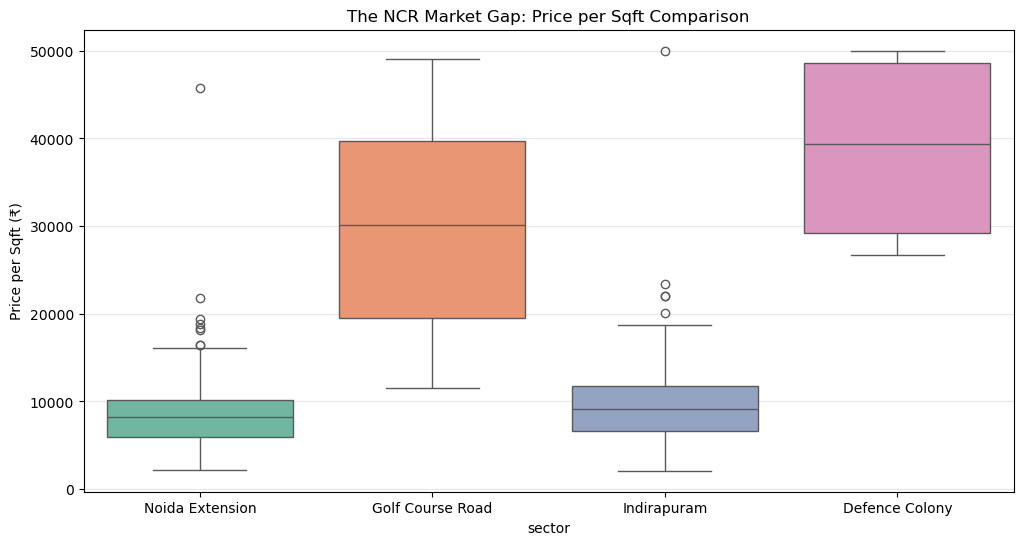

In [73]:
# Compare the "Volume King" vs the "Value King"
comparison_list = ['Noida Extension', 'Defence Colony', 'Golf Course Road', 'Indirapuram']
df_comp = df[df['sector'].isin(comparison_list)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='sector', y='pps', data=df_comp, palette='Set2')
plt.title('The NCR Market Gap: Price per Sqft Comparison')
plt.ylabel('Price per Sqft (₹)')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Observation
- Price per square foot varies sharply across selected sectors.
- Defence Colony shows the highest median price per sqft with a relatively tight distribution.
- Golf Course Road exhibits a high median price but with substantial spread, indicating a wide range of property types.
- Noida Extension and Indirapuram have significantly lower median prices per sqft, with comparatively narrower distributions.

### Insight
- Sector-level differences capture the true pricing gap in the NCR real estate market more effectively than city-level analysis.
- Premium central locations such as Defence Colony command consistently high per-unit prices, reflecting strong desirability and limited supply.
- Wider spreads in sectors like Golf Course Road indicate mixed inventory, ranging from mid-range to ultra-luxury properties.
- Peripheral sectors offer lower price efficiency, highlighting affordability but lower location premiums.

### Modeling Impact
- Sector is a critical high-granularity location feature and should be prioritized in modeling.
- Price per sqft is a strong signal for identifying premium versus affordable micro-markets.
- Sector-level encoding will significantly improve both price prediction accuracy and recommendation relevance.


In [74]:
# See if '0' floor properties are mostly houses or flats
print(df[df['floor'] == 0]['prop_type'].value_counts())

prop_type
Apartment            6611
Independent House    1459
Builder Floor         623
Plot                   71
Name: count, dtype: int64


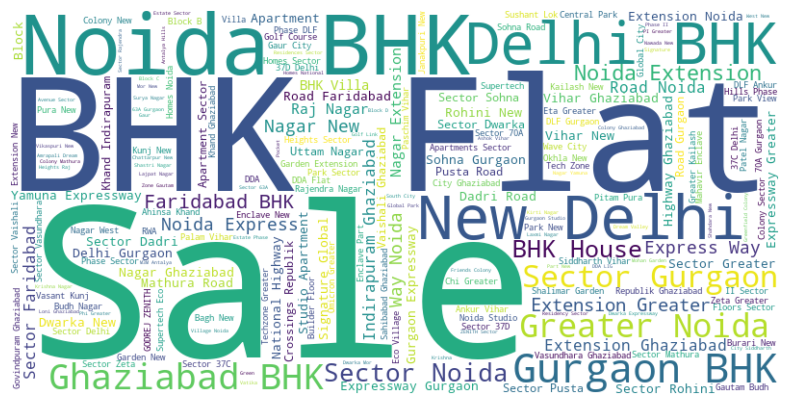

In [75]:
from wordcloud import WordCloud
# Visualize the most common words in property titles
text = " ".join(title for title in df.title)
wordcloud = WordCloud(background_color="white", width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Observation
- Property titles are dominated by location-related terms such as city names and sector identifiers.
- Configuration-related terms like BHK appear prominently across listings.
- Property type descriptors such as apartment or house are present but less dominant.

### Insight
- Sellers emphasize location and configuration as primary selling points when marketing properties.
- The prominence of sector and city names reinforces the importance of micro-location in the NCR real estate market.
- Textual listing data implicitly encodes key valuation drivers already identified through numerical analysis.

### Modeling Impact
- Location and configuration features are validated as high-importance predictors.
- Text-based features such as keywords from titles can be leveraged for feature extraction or recommendation systems.
- The word cloud provides qualitative validation of the quantitative feature importance observed earlier in the analysis.


C:\Users\Asus\AppData\Local\Temp\ipykernel_12592\1960840273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prop_type', y='pps', data=df, estimator='median', palette='viridis')


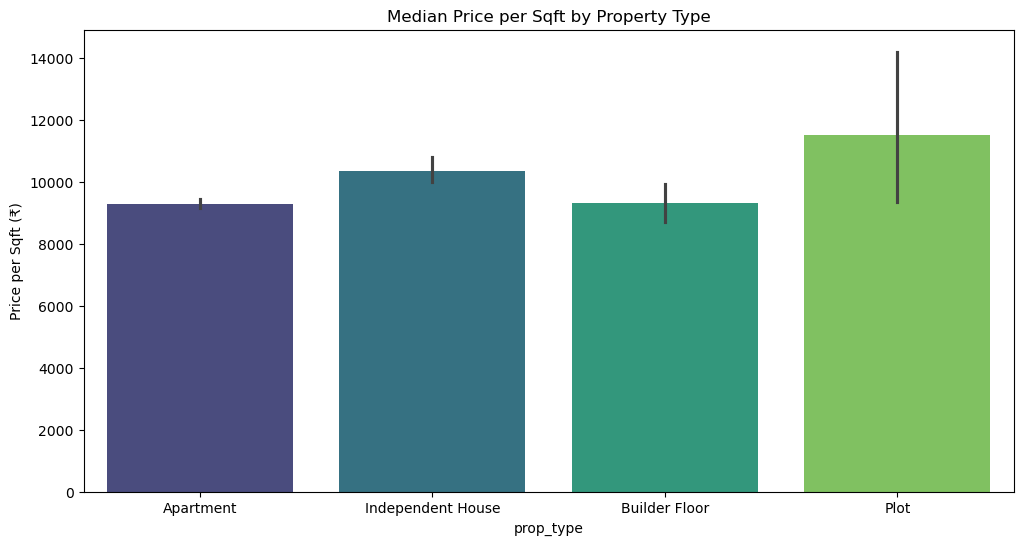

In [76]:
plt.figure(figsize=(12, 6))
# Comparing Price per Sqft across types
sns.barplot(x='prop_type', y='pps', data=df, estimator='median', palette='viridis')
plt.title('Median Price per Sqft by Property Type')
plt.ylabel('Price per Sqft (₹)')
plt.show()

### Observation
- Median price per square foot differs across property types.
- Plots command the highest median price per sqft, followed by independent houses.
- Apartments and builder floors exhibit relatively lower and closer median values.
- Variability is highest for plots, indicating a wide range of valuations within this category.

### Insight
- Property type plays a meaningful role in price formation, beyond size and location.
- Higher per-sqft prices for plots reflect land value premiums and scarcity.
- Apartments and builder floors show more standardized pricing due to uniform construction and supply characteristics.

### Modeling Impact
- Property type should be included as an important categorical feature in the pricing model.
- Interaction effects between property type and location may further improve predictions.
- Higher variance categories such as plots may benefit from separate modeling considerations or additional features.


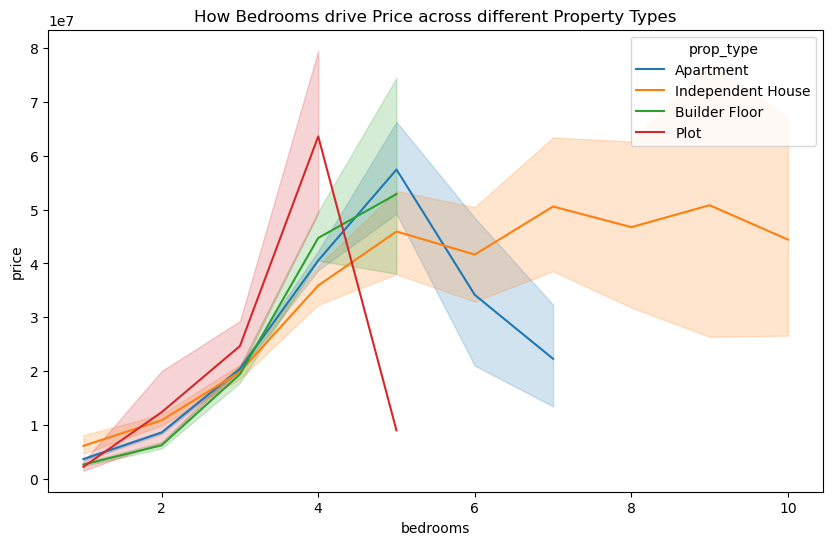

In [77]:
# See if the relationship between Bedrooms and Price changes by Prop_type
plt.figure(figsize=(10, 6))
sns.lineplot(data=df[df['bedrooms'] > 0], x='bedrooms', y='price', hue='prop_type')
plt.title('How Bedrooms drive Price across different Property Types')
plt.show()

### Observation
- The relationship between number of bedrooms and price differs across property types.
- Apartments and builder floors show a steady increase in price up to mid-range bedroom counts, after which the trend weakens.
- Independent houses continue to show price growth with higher bedroom counts, though with increased variability.
- Plot-based properties display irregular patterns due to limited observations and high variance.

### Insight
- Bedroom count does not have a uniform impact on price across property types.
- For apartments and builder floors, additional bedrooms beyond a certain point do not proportionally increase price, likely due to space constraints and standardized layouts.
- Independent houses benefit more consistently from higher bedroom counts, reflecting larger plot sizes and flexible construction.
- Irregular trends for plots highlight the dominance of land value over built configuration.

### Modeling Impact
- Bedroom count should not be modeled as a standalone linear feature.
- Strong interaction exists between bedroom count and property type, which should be captured explicitly or through non-linear models.
- Tree-based or ensemble models are well suited to learn these conditional relationships without manual feature engineering.


In [78]:
# Check counts for the last two important categorical features
print("Furnishing Status:\n", df['furnished'].value_counts())
print("\nFacing Direction:\n", df['facing'].value_counts())

Furnishing Status:
 furnished
Semi-Furnished     5832
Unfurnished        2780
Unknown            1639
Fully-Furnished     287
Name: count, dtype: int64

Facing Direction:
 facing
Unknown       8291
East          2073
North-East      56
North           46
West            23
North-West      15
South-East      14
South           11
South-West       9
Name: count, dtype: int64


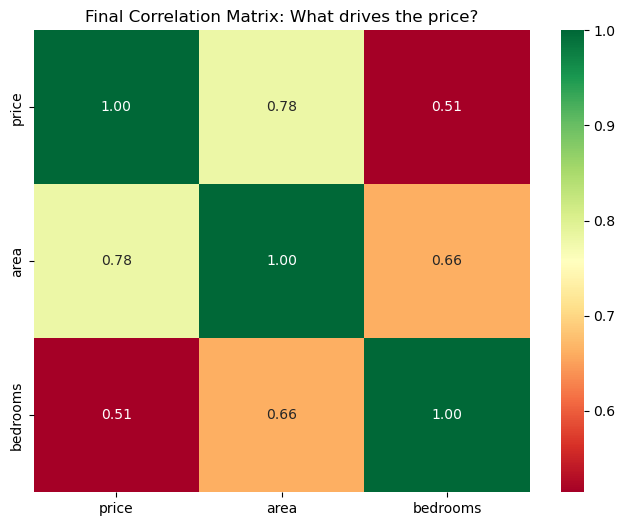

Final Area vs Price Correlation: 0.78


In [79]:
# 4. Correlation Analysis (After Cleaning)
plt.figure(figsize=(8, 6))
correlation_matrix = df[['price', 'area', 'bedrooms']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Final Correlation Matrix: What drives the price?')
plt.show()

print(f"Final Area vs Price Correlation: {correlation_matrix.loc['area', 'price']:.2f}")

### Observation
- Price has a strong positive correlation with area (≈ 0.78).
- The correlation between price and number of bedrooms is moderate (≈ 0.51).
- Area and bedrooms are themselves strongly correlated (≈ 0.66), indicating dependency between these features.

### Insight
- Area is the strongest numerical driver of property price in the dataset.
- Bedroom count provides additional information but largely acts as a proxy for property size.
- The strong correlation between area and bedrooms suggests redundancy and potential multicollinearity.

### Modeling Impact
- Area should be treated as a primary feature in all pricing models.
- Bedroom count should be included but interpreted in conjunction with area.
- Linear models must handle multicollinearity carefully, while tree-based and ensemble models are naturally better suited for this feature structure.


### Initial Hypotheses
- Property price increases non-linearly with area.
- Location (sector-level) has a stronger influence on price than bedroom count.
- Price per square foot is a more stable indicator of location value than absolute price.


### Key Takeaways from Initial EDA
- Area is the strongest numerical driver of price.
- Location effects dominate structural features.
- Bedroom count is informative only in context.
- Price per sqft is a stable indicator of location value.
- Non-linear, interaction-aware models are required.
